# Projet 4 : Réseaux de neurones (MLP) sur MNIST

## Problématique
Le problème de ce projet est de reconnaître automatiquement les chiffres manuscrits (0 à 9) à partir d’images avec un ordinateur.

## Dataset
Nous utilisons le dataset MNIST composé de 60 000 images d'entraînement et 10 000 images de test.

## Méthode
Nous allons construire un modèle de type MLP (Multi-Layer Perceptron) et analyser ses performances.

Importation des librairies

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

torch.manual_seed(42)

Transformation(Ça convertit l’image en tenseur (format que le modèle comprend)) et chargement des données MNIST

In [2]:
# Transformation : normalisation automatique (0 → 1)
transform = transforms.Compose([
    transforms.ToTensor()
])
# Chargement des données MNIST
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


Exploration des données

In [3]:
print(len(train_dataset))
print(len(test_dataset))

60000
10000


 Création des dataloaders

In [4]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Vérification

In [5]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


Aplatissement des images

In [6]:
images = images.view(-1, 28*28)

Visualisation

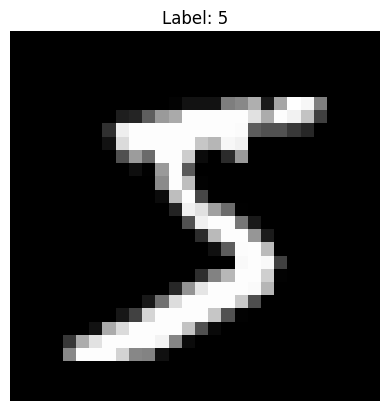

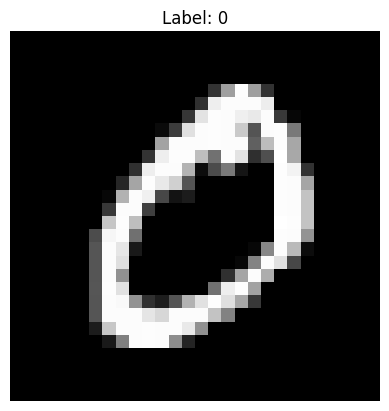

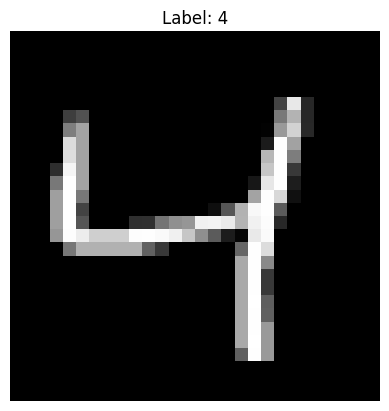

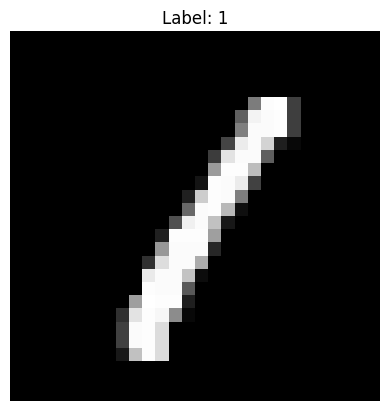

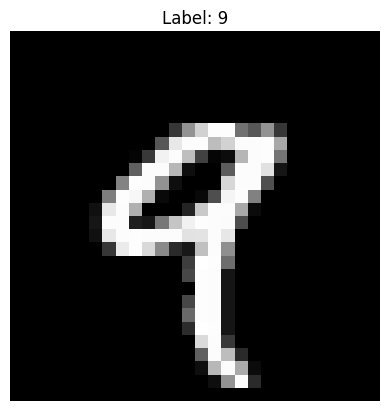

In [7]:
# Affichage de quelques images
for i in range(5):
    image, label = train_dataset[i]
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

Moèle 1 : Baseline simple

In [8]:
# Modèle simple
model_simple = nn.Sequential(
    nn.Linear(784, 10)
)

Modèle 2 : MLP

In [9]:
# Modèle MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MLP()

Calcul du nombre de paramètres

In [10]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print("Params Simple:", count_params(model_simple))
print("Params MLP:", count_params(model))

Params Simple: 7850
Params MLP: 109386


Fonction de perte + optimiseur

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Entraînement

In [12]:
def train_model(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    losses_per_epoch = [] # Initialiser la liste pour stocker les pertes

    for epoch in range(3):
        total_loss = 0

        for images, labels in train_loader:
            images = images.view(images.size(0), -1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        losses_per_epoch.append(total_loss) # Ajouter la perte totale pour l'époque
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
    return losses_per_epoch # Retourner la liste des pertes

Entrainé les deux modèles

In [13]:
print("Training Simple Model")
train_model(model_simple)

print("\nTraining MLP Model")
train_model(model)

Training Simple Model
Epoch 1, Loss: 508.3533
Epoch 2, Loss: 303.4665
Epoch 3, Loss: 277.0054

Training MLP Model
Epoch 1, Loss: 319.6839
Epoch 2, Loss: 135.7489
Epoch 3, Loss: 94.4012


[319.68389904499054, 135.7488916888833, 94.40119456779212]

Evaluation (Accuracy et F1-score)

In [14]:
def evaluate_model(model, test_loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.view(images.size(0), -1)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(predicted.numpy())

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    return acc, f1, y_true, y_pred

Evaluation des deux modèles

In [15]:
acc_simple, f1_simple, y_true_s, y_pred_s = evaluate_model(model_simple, test_loader)
acc_mlp, f1_mlp, y_true_m, y_pred_m = evaluate_model(model, test_loader)

print("SIMPLE MODEL")
print(f"Accuracy: {acc_simple:.4f}")
print(f"F1-score: {f1_simple:.4f}")

print("\nMLP MODEL")
print(f"Accuracy: {acc_mlp:.4f}")
print(f"F1-score: {f1_mlp:.4f}")

SIMPLE MODEL
Accuracy: 0.9219
F1-score: 0.9217

MLP MODEL
Accuracy: 0.9704
F1-score: 0.9704


Matrice de confusion pour les deux modèles

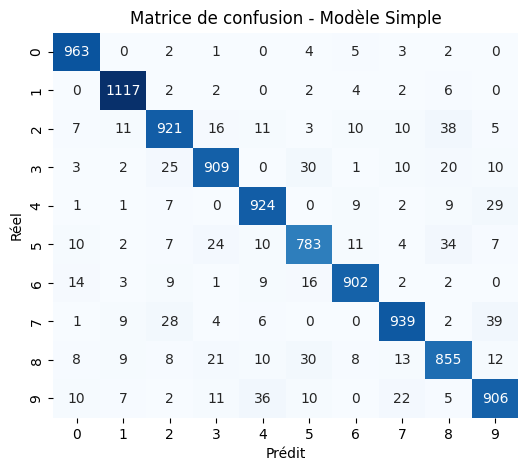

In [16]:
# Matrice de confusion modèle simple
cm_simple = confusion_matrix(y_true_s, y_pred_s)

plt.figure(figsize=(6,5))
sns.heatmap(cm_simple, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=range(10), yticklabels=range(10))
plt.title("Matrice de confusion - Modèle Simple")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

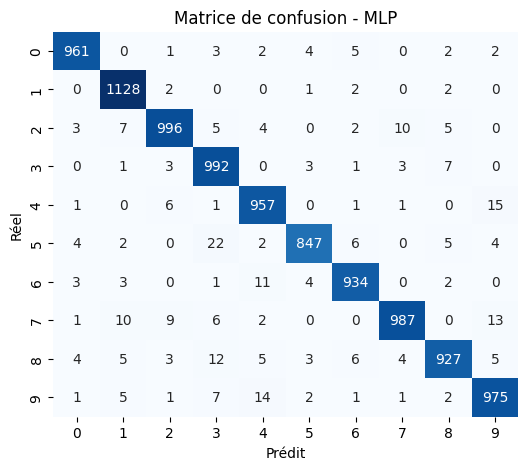

In [17]:
# Matrice de confusion modèle MLP
cm_mlp = confusion_matrix(y_true_m, y_pred_m)

plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=range(10), yticklabels=range(10))
plt.title("Matrice de confusion - MLP")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

Comparaison des deux modeles

In [18]:
print(f"Simple Model -> Accuracy: {acc_simple:.4f}, F1: {f1_simple:.4f}")
print(f"MLP Model    -> Accuracy: {acc_mlp:.4f}, F1: {f1_mlp:.4f}")

Simple Model -> Accuracy: 0.9219, F1: 0.9217
MLP Model    -> Accuracy: 0.9704, F1: 0.9704


Le modèle simple atteint une accuracy de 92.19%, tandis que le modèle MLP atteint 97.04%.

Cette différence s'explique par le fait que le modèle simple est une régression linéaire, incapable de capturer des relations complexes.

Le MLP, grâce à ses couches cachées et ses fonctions d’activation, apprend des représentations plus riches des données.

Epoch 1, Loss: 317.5422
Epoch 2, Loss: 128.7881
Epoch 3, Loss: 87.6645


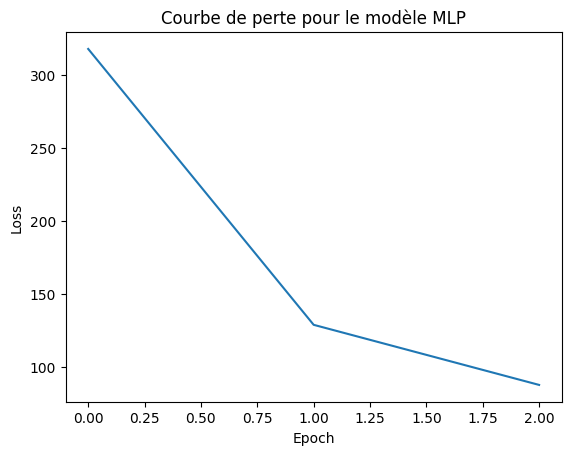

In [19]:
# Pour obtenir une courbe de perte claire dès le départ, réinitialisez et réentraînez le modèle MLP.
# Cela permet d'observer la diminution de la perte à partir d'un état non entraîné.
model_for_loss_plot = MLP() # Créer une nouvelle instance pour le tracé
losses_mlp_plot = train_model(model_for_loss_plot) # Entraîner cette nouvelle instance et enregistrer les pertes

plt.plot(losses_mlp_plot)
plt.title("Courbe de perte pour le modèle MLP")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Test sur les modèles

In [20]:
model = model_simple
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Sequential(
  (0): Linear(in_features=784, out_features=10, bias=True)
)

In [21]:
model = MLP()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

MLP(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

## Analyse des résultats

Le modèle MLP atteint une bonne précision sur le dataset MNIST.

Cependant, certaines erreurs apparaissent entre des chiffres similaires comme 3 et 5 ou 4 et 9.

Cela s'explique par la similarité visuelle entre certains chiffres manuscrits.

Le modèle MLP reste limité pour les images car il ne capture pas les structures spatiales.

Un CNN serait plus performant pour ce type de données.

## Conclusion

Nous avons construit un modèle MLP pour la reconnaissance de chiffres manuscrits.

Les résultats sont satisfaisants avec une bonne accuracy.

Cependant, des améliorations sont possibles en utilisant des architectures plus avancées comme les CNN.

Test visuel: réel vs prédit (MNIST)

In [22]:
def test_predictions(model, test_loader, num_images=10):

    model.eval()

    images_batch, labels_batch = next(iter(test_loader))

    images = images_batch.view(images_batch.size(0), -1)

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    plt.figure(figsize=(12, 5))

    for i in range(num_images):
        plt.subplot(2, 5, i+1)

        plt.imshow(images_batch[i].squeeze(), cmap='gray')

        plt.title(f"Réel: {labels_batch[i].item()}\nPrédit: {predicted[i].item()}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

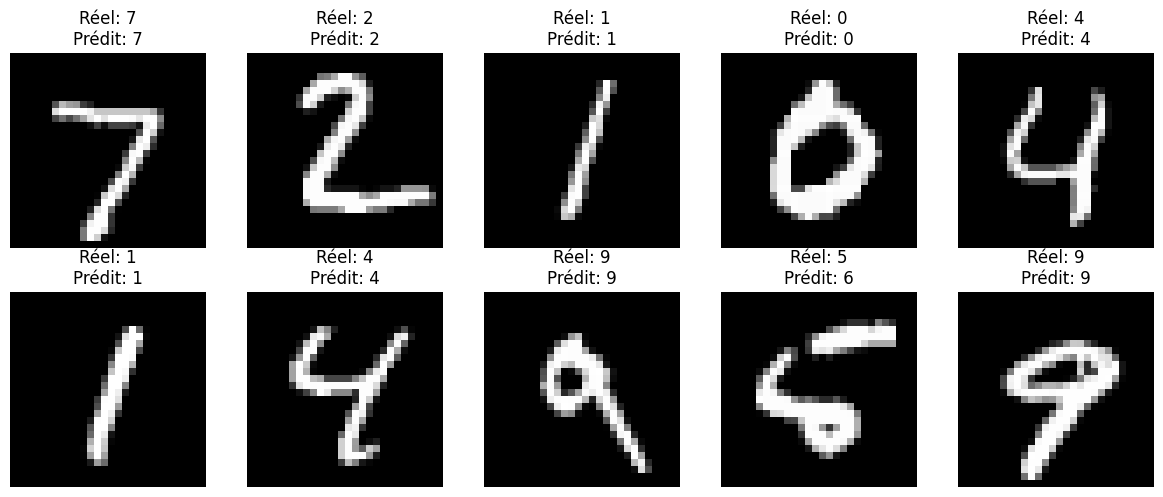

In [23]:
# Test avec le modèle simple
test_predictions(model_simple, test_loader, num_images=10)

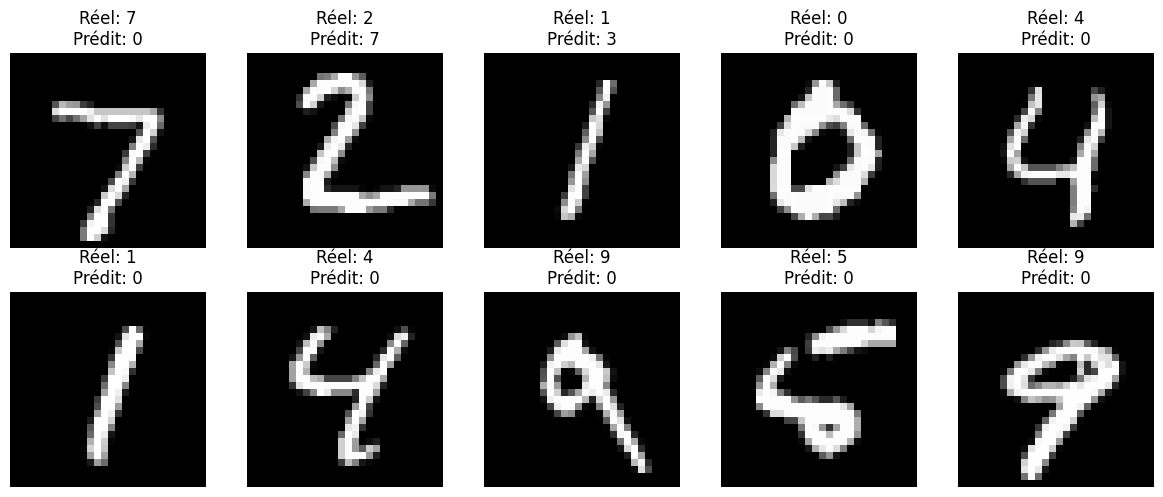

In [24]:
# Test avec le MLP
test_predictions(model, test_loader, num_images=10)

## Interprétation

La visualisation des prédictions montre la capacité du modèle à reconnaître correctement les chiffres manuscrits. Le modèle MLP présente un bon taux de réussite, avec toutefois quelques erreurs sur des chiffres visuellement similaires. Le modèle simple, quant à lui, montre plus d’erreurs de classification.

Affichage des erreurs

In [25]:
def show_errors(model, test_loader, num_images=10):

    model.eval()

    images_batch, labels_batch = next(iter(test_loader))
    images = images_batch.view(images_batch.size(0), -1)

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    errors = 0
    plt.figure(figsize=(12, 5))

    for i in range(len(images_batch)):
        if predicted[i] != labels_batch[i]:

            plt.subplot(2, 5, errors+1)
            plt.imshow(images_batch[i].squeeze(), cmap='gray')
            plt.title(f"R:{labels_batch[i].item()} P:{predicted[i].item()}")
            plt.axis('off')

            errors += 1

        if errors == num_images:
            break

    plt.tight_layout()
    plt.show()

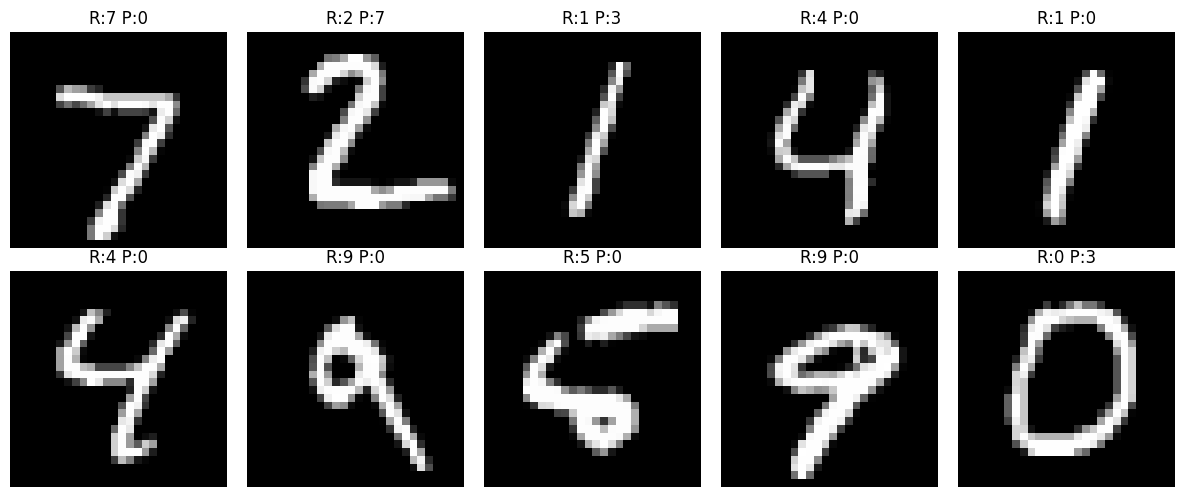

In [26]:
show_errors(model, test_loader, num_images=10)